Loaded metal_vae
Generating metal_vae  enc_dim=16...
  saved metal_vae_generated.wav


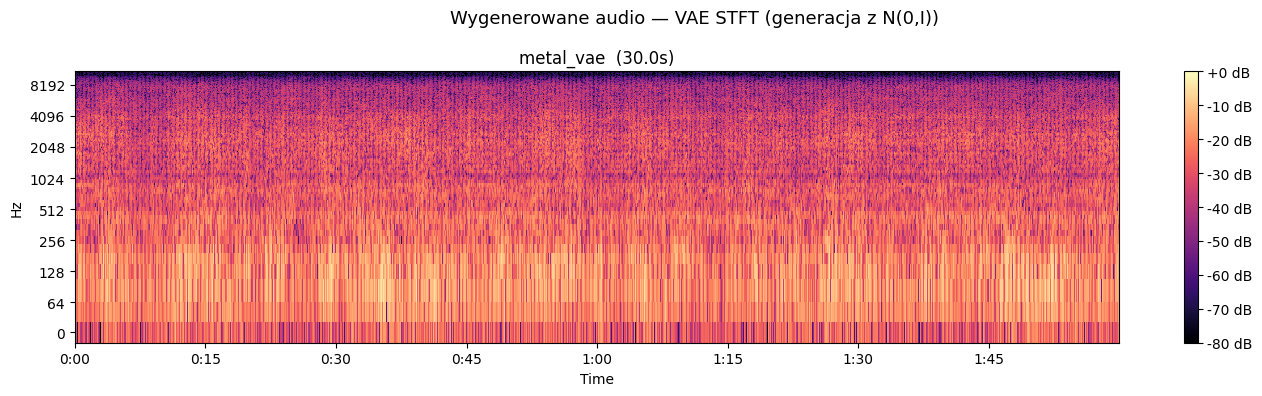


=== Odsłuch ===
metal_vae:


In [3]:
import os
import numpy as np
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from IPython.display import Audio, display

N_FFT      = 1024
HOP_LENGTH = 512
SR         = 22050
THRESHOLD  = -100.0
OUT_DIR    = "comparison_output"
os.makedirs(OUT_DIR, exist_ok=True)

@tf.keras.utils.register_keras_serializable()
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

models_vae = {}
for name in ["metal_vae"]:
    enc_path = f"new models/{name}_encoder.keras"
    dec_path = f"new models/{name}_decoder.keras"
    if os.path.exists(enc_path) and os.path.exists(dec_path):
        models_vae[name] = {
            "encoder": keras.models.load_model(enc_path),
            "decoder": keras.models.load_model(dec_path),
        }
        print(f"Loaded {name}")
    else:
        print(f"Missing {name}")

def generate_audio(decoder, n_frames=1292, enc_dim=16, smoothing=0.92):
    z = np.random.randn(1, enc_dim).astype(np.float32)
    all_z = [z[0]]
    for _ in range(n_frames - 1):
        noise = np.random.randn(enc_dim).astype(np.float32)
        all_z.append(smoothing * all_z[-1] + (1 - smoothing) * noise)
    Z       = np.array(all_z, dtype=np.float32)
    mag_rec = decoder.predict(Z, batch_size=512, verbose=0)
    S_norm  = np.clip(mag_rec.T, -1, 1)
    S_db    = (S_norm + 1) / 2 * (-THRESHOLD) + THRESHOLD
    S_mag   = librosa.db_to_amplitude(S_db)
    audio   = librosa.griffinlim(S_mag, n_iter=64, hop_length=HOP_LENGTH)
    audio   = audio / (np.max(np.abs(audio)) + 1e-12)
    return audio

generated = {}
for name, m in models_vae.items():
    dummy   = np.zeros((1, N_FFT // 2 + 1), dtype=np.float32)
    enc_dim = m["encoder"].predict(dummy, verbose=0)[0].shape[-1]
    print(f"Generating {name}  enc_dim={enc_dim}...")
    audio = generate_audio(m["decoder"], n_frames=1292, enc_dim=enc_dim)
    generated[name] = audio
    sf.write(os.path.join(OUT_DIR, f"{name}_generated.wav"), audio, SR)
    print(f"  saved {name}_generated.wav")

n = len(generated)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]
fig.suptitle("Wygenerowane audio — VAE STFT (generacja z N(0,I))", fontsize=13)

for ax, (name, audio) in zip(axes, generated.items()):
    D   = librosa.amplitude_to_db(np.abs(librosa.stft(audio, n_fft=512)), ref=np.max)
    img = librosa.display.specshow(D, sr=SR, x_axis="time", y_axis="log", ax=ax)
    ax.set_title(f"{name}  ({len(audio)/SR:.1f}s)")
    plt.colorbar(img, ax=ax, format="%+2.0f dB")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "vae_generated_spectrograms.png"), dpi=120, bbox_inches="tight")
plt.show()

print("\n=== Odsłuch ===")
for name, audio in generated.items():
    print(f"{name}:")
    display(Audio(audio, rate=SR))